In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("stud.csv")

In [ ]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
print(df['gender'].unique())

['female' 'male']


In [ ]:
print(df['gender'].value_counts())

gender
female    518
male      482
Name: count, dtype: int64


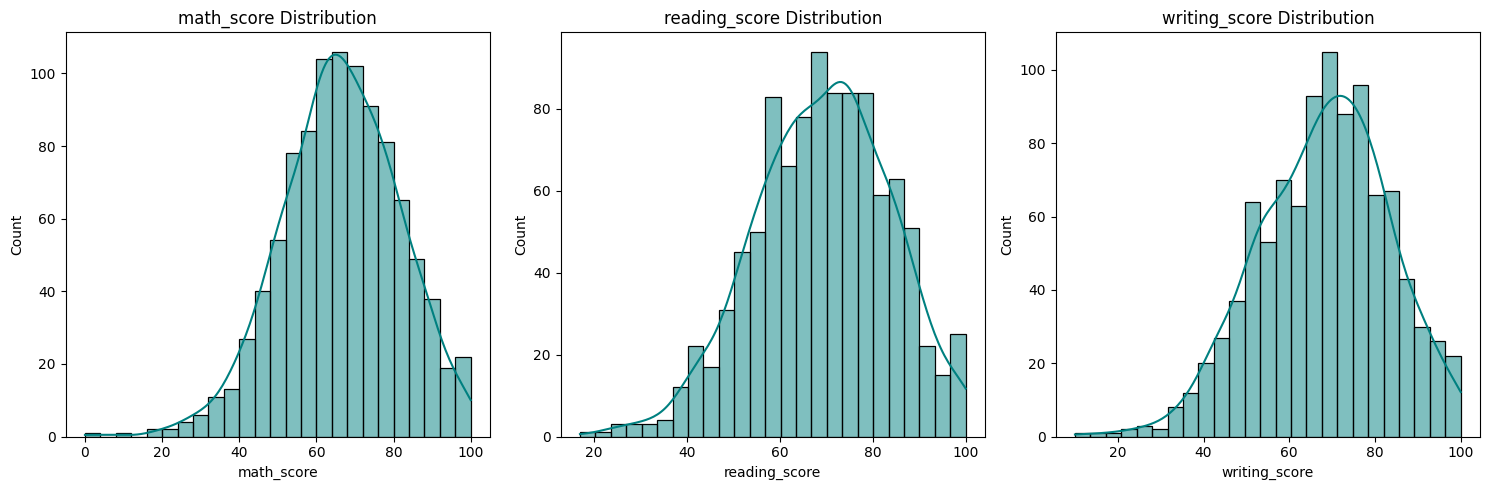

In [ ]:
plt.figure(figsize=(15,5))
for i, col in enumerate(['math_score', 'reading_score', 'writing_score']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, color='teal', bins=25)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()


Average scores by gender:
         math_score  reading_score  writing_score
gender                                          
female   63.633205      72.608108      72.467181
male     68.728216      65.473029      63.311203


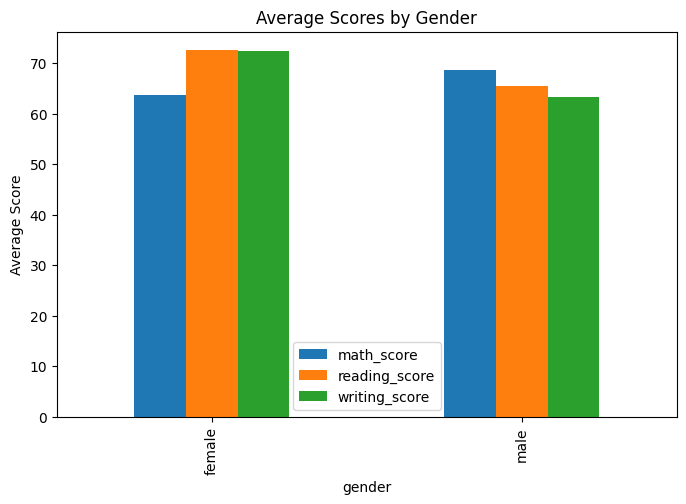

In [ ]:
avg_scores = df.groupby('gender')[['math_score', 'reading_score', 'writing_score']].mean()
print("\nAverage scores by gender:\n", avg_scores)

avg_scores.plot(kind='bar', figsize=(8,5))
plt.title("Average Scores by Gender")
plt.ylabel("Average Score")
plt.show()

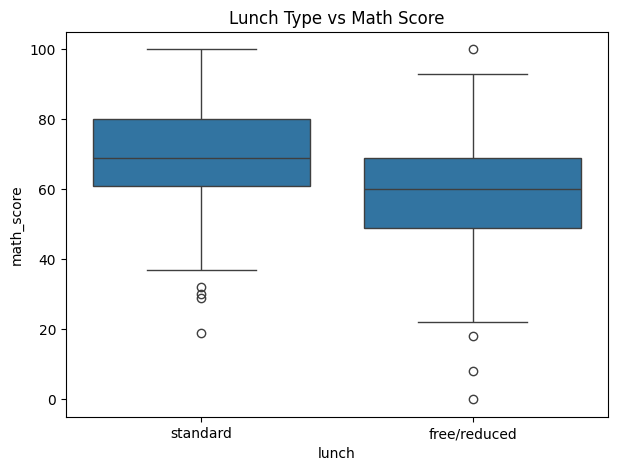

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='lunch', y='math_score', data=df)
plt.title("Lunch Type vs Math Score")
plt.show()

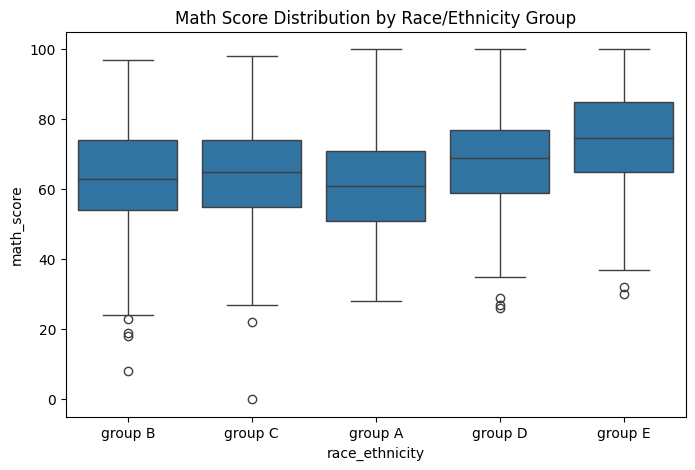

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='race_ethnicity', y='math_score', data=df)
plt.title("Math Score Distribution by Race/Ethnicity Group")
plt.show()

In [ ]:
corr = df[['math_score', 'reading_score', 'writing_score']].corr()
print("\nScore Correlations:\n", corr)


Score Correlations:
                math_score  reading_score  writing_score
math_score       1.000000       0.817580       0.802642
reading_score    0.817580       1.000000       0.954598
writing_score    0.802642       0.954598       1.000000


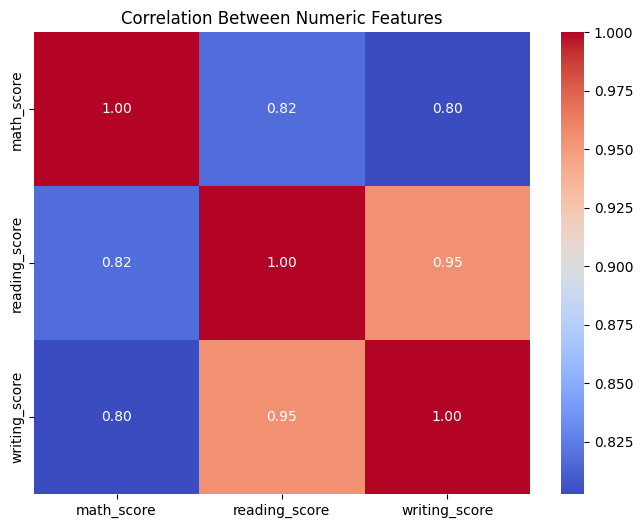

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

In [ ]:
df.describe(include='object')

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [ ]:
df['total_score']=df["math_score"]+df["reading_score"]+df["writing_score"]
df["average_score"]=df["total_score"]/3
print(df.head())

   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   total_score  average_score  
0          218      72.666667  
1          247      82.333333  
2          278      92.666667  
3          148      49.3

In [ ]:
full_marks_count = df[
    (df['math_score'] == 100) &
    (df['reading_score'] == 100) &
    (df['writing_score'] == 100)
].shape[0]

print(f"Number of students with full marks in reading, writing, and maths: {full_marks_count}")

Number of students with full marks in reading, writing, and maths: 3


In [ ]:
less_than_20_count = df[
    (df['math_score'] <= 20) &
    (df['reading_score'] <= 20) &
    (df['writing_score'] <= 20)
].shape[0]

print(f"Number of students with at least one score less than 20: {less_than_20_count}")

Number of students with at least one score less than 20: 1
